## Diseño de redes

In [9]:
import pandas as pd

data = pd.read_excel("data/Tsp-1.xlsx")
data.columns
print(data.iloc[0,:])

colonia          U H FOVISSSTE ESTADI
Calle                          LISBOA
# de casa                          28
Código postal                   44307
Unnamed: 4                Guadalajara
Name: 0, dtype: object


In [42]:
import pandas as pd
from geopy.geocoders import ArcGIS
import time

def pre_procesar_direcciones(ruta_entrada, ruta_salida, cantidad_a_procesar=None):
    df = pd.read_excel(ruta_entrada)
    
    if cantidad_a_procesar:
        df = df.head(cantidad_a_procesar).copy() 
    
    geolocator = ArcGIS()

    lats = []
    lons = []
    encontrados = []

    print(f" Procesando {len(df)} direcciones. ")

    for index, row in df.iterrows():
        calle = str(row['Calle']).replace('#', '').strip()
        numero = str(row['# de casa']).replace('#', '').strip()
        colonia = str(row['colonia']).strip()
        ciudad = str(row['Unnamed: 4']).strip()
        
        direccion = f"{calle} {numero}, {colonia}, {ciudad}, Mexico"
        
        try:
            location = geolocator.geocode(direccion, timeout=10)
            if location:
                lats.append(location.latitude)
                lons.append(location.longitude)
                encontrados.append(True)
                print(f"    {index}: OK")
            else:
                lats.append(None)
                lons.append(None)
                encontrados.append(False)
                print(f"    {index}: No encontrado")
        except:
            lats.append(None)
            lons.append(None)
            encontrados.append(False)
            print(f"    {index}: Error de conexión")

        time.sleep(0.7)

    df['latitud'] = lats
    df['longitud'] = lons
    df["id_original_excel"] = df.index + 1
    
    df_final = df[df['latitud'].notnull()]
    
    df_final.to_csv(ruta_salida, index=False)
    print(f"\n Guardado exitosamente en '{ruta_salida}'. Nodos válidos: {len(df_final)}")

 

In [43]:
pre_procesar_direcciones('data/Tsp-1.xlsx', 'direcciones_lat_lon.csv')

 Procesando 289 direcciones. 
    0: OK
    1: OK
    2: OK
    3: OK
    4: OK
    5: OK
    6: OK
    7: OK
    8: OK
    9: OK
    10: OK
    11: OK
    12: OK
    13: OK
    14: OK
    15: OK
    16: OK
    17: OK
    18: OK
    19: OK
    20: OK
    21: OK
    22: OK
    23: OK
    24: OK
    25: OK
    26: OK
    27: OK
    28: OK
    29: OK
    30: OK
    31: OK
    32: OK
    33: OK
    34: OK
    35: OK
    36: OK
    37: OK
    38: OK
    39: OK
    40: OK
    41: OK
    42: OK
    43: OK
    44: OK
    45: OK
    46: OK
    47: OK
    48: OK
    49: OK
    50: OK
    51: OK
    52: OK
    53: OK
    54: OK
    55: OK
    56: OK
    57: OK
    58: OK
    59: OK
    60: OK
    61: OK
    62: OK
    63: OK
    64: OK
    65: OK
    66: OK
    67: OK
    68: OK
    69: OK
    70: OK
    71: OK
    72: OK
    73: OK
    74: OK
    75: OK
    76: OK
    77: OK
    78: OK
    79: OK
    80: OK
    81: OK
    82: OK
    83: OK
    84: OK
    85: OK
    86: OK
    87: OK
    88: OK
 

In [51]:
import pandas as pd
from geopy.distance import geodesic
from itertools import combinations

def construir_grafo_completo(ruta_csv_procesado, n_nodos, semilla):
    
    df = pd.read_csv(ruta_csv_procesado)
    
    if n_nodos > len(df):
        n_nodos = len(df)
        
    df_random = df.sample(n=n_nodos, random_state=semilla).reset_index(drop=True)

    info_nodos = {}
    coords_list = [] 
    
    for id_nodo, row in df_random.iterrows():
        coords_list.append((id_nodo, row['latitud'], row['longitud']))
        direccion_texto = f"{row.get('Calle', '')} {row.get('# de casa', '')}, {row.get('colonia', '')}"
        
        info_nodos[id_nodo] = {
            'lat': row['latitud'],
            'lon': row['longitud'],
            'nombre': direccion_texto,
            'id_original_excel': row.get('id_original_excel', 'N/A')
        }

    grafo_distancias = {}
    for (id1, lat1, lon1), (id2, lat2, lon2) in combinations(coords_list, 2):
        dist = geodesic((lat1, lon1), (lat2, lon2)).kilometers
        grafo_distancias[(id1, id2)] = round(dist, 4)
        
    return grafo_distancias, info_nodos

## Algoritmo genético

In [ ]:
import random
import time
import operator

def calcular_fitness(ruta, grafo_distancias):
    """
    Calcula la distancia total de una ruta.
    Fitness = 1 / Distancia (porque queremos minimizar distancia).
    """
    distancia_total = 0
    for i in range(len(ruta)):
        origen = ruta[i]
        destino = ruta[(i + 1) % len(ruta)]
        
        if (origen, destino) in grafo_distancias:
            distancia_total += grafo_distancias[(origen, destino)]
        elif (destino, origen) in grafo_distancias:
            distancia_total += grafo_distancias[(destino, origen)]
        else:
            distancia_total += 999999 
            
    return distancia_total, 1 / distancia_total

def crear_poblacion(tam_poblacion, lista_nodos_ids):
    poblacion = []
    for _ in range(tam_poblacion):
        individuo = random.sample(lista_nodos_ids, len(lista_nodos_ids))
        poblacion.append(individuo)
    return poblacion

def seleccion_ruleta(poblacion, fitness_resultados):
    """
    Selecciona padres basándose en su probabilidad (Fitness relativo).
    """
    scores = [f[1] for f in fitness_resultados]
    sum_scores = sum(scores)
    
    probs = [s / sum_scores for s in scores]
    
    seleccionados = random.choices(poblacion, weights=probs, k=len(poblacion))
    return seleccionados

def cruzar_ox1(padre1, padre2):
    """
    Cruce especial para TSP. Mantiene una sub-sección del padre 1
    y rellena con el padre 2 en orden, evitando duplicados.
    """
    size = len(padre1)
    
    punto1 = random.randint(0, size - 1)
    punto2 = random.randint(0, size - 1)
    
    inicio = min(punto1, punto2)
    fin = max(punto1, punto2)
    
    hijo = [None] * size
    hijo[inicio:fin+1] = padre1[inicio:fin+1]
    
    pos_actual = 0
    for ciudad in padre2:
        if ciudad not in hijo:
            while hijo[pos_actual] is not None:
                pos_actual += 1
            hijo[pos_actual] = ciudad
            
    return hijo

def mutar(individuo, tasa_mutacion):
    """Intercambia dos ciudades de lugar al azar."""
    if random.random() < tasa_mutacion:
        idx1, idx2 = random.sample(range(len(individuo)), 2)
        individuo[idx1], individuo[idx2] = individuo[idx2], individuo[idx1]
    return individuo


def algoritmo_genetico_tsp(grafo_distancias, lista_nodos_ids, tam_poblacion, generaciones, tasa_mutacion, elite_size):
    
    start_time = time.time()
    
    poblacion = crear_poblacion(tam_poblacion, lista_nodos_ids)
    
    mejor_ruta_global = None
    mejor_distancia_global = float('inf')
    
    for i in range(generaciones):
        resultados_fitness = []
        for individuo in poblacion:
            dist, score = calcular_fitness(individuo, grafo_distancias)
            resultados_fitness.append((dist, score))
            
            if dist < mejor_distancia_global:
                mejor_distancia_global = dist
                mejor_ruta_global = individuo[:] 
        
        ordenados = sorted(zip(poblacion, resultados_fitness), key=lambda x: x[1][0])
        nueva_poblacion = [x[0] for x in ordenados[:elite_size]]

        pool_padres = seleccion_ruleta(poblacion, resultados_fitness)
        
        while len(nueva_poblacion) < tam_poblacion:
            padre_a = random.choice(pool_padres)
            padre_b = random.choice(pool_padres)
            
            hijo = cruzar_ox1(padre_a, padre_b)
            hijo = mutar(hijo, tasa_mutacion)
            
            nueva_poblacion.append(hijo)
            
        poblacion = nueva_poblacion

    end_time = time.time()
    tiempo_computo = end_time - start_time
    
    return {
        'mejor_ruta': mejor_ruta_global,
        'mejor_distancia': mejor_distancia_global,
        'tiempo_segundos': round(tiempo_computo, 4)
    }

## Hormigas

In [114]:
import numpy as np
import random
import time

def inicializar_feromonas(n_nodos, feromona_inicial=1.0):
    """Inicializa la matriz de feromonas con un valor uniforme."""
    return np.full((n_nodos, n_nodos), feromona_inicial)

def calcular_heuristica(grafo_distancias, n_nodos):
    """
    Calcula la información heurística (eta): 1 / distancia.
    Protegida contra distancias cero.
    """
    heuristica = np.zeros((n_nodos, n_nodos))
    epsilon = 0.0001 
    
    for i in range(n_nodos):
        for j in range(n_nodos):
            if i != j:
                distancia = grafo_distancias.get((i, j), grafo_distancias.get((j, i), -1))
                if distancia <= 0:
                    distancia = epsilon 
                
                # Eta
                heuristica[i, j] = 1.0 / distancia
                
    return heuristica

def seleccionar_siguiente_ciudad(actual, ciudades_permitidas, feromonas, heuristica, alpha, beta):
    """Implementa la regla de probabilidad de transición (Ruleta de ACO)."""
    
    numeradores = []
    
    for siguiente in ciudades_permitidas:
        tau = feromonas[actual, siguiente]
        eta = heuristica[actual, siguiente]
        
        numerador = (tau ** alpha) * (eta ** beta)
        numeradores.append(numerador)
        
    denominador = sum(numeradores)
    
    if denominador == 0:
        return random.choice(ciudades_permitidas)
        
    probabilidades = [n / denominador for n in numeradores]
    
    seleccion = random.choices(ciudades_permitidas, weights=probabilidades, k=1)[0]
    return seleccion

In [115]:
def aco_tsp(grafo_distancias, n_nodos,
            n_hormigas, n_iteraciones, feromona_inicial=1.0, Q=1.0,
            alpha=1.0, beta=2.0, rho=0.5):
    """
    Algoritmo de Colonia de Hormigas para el TSP.
    
    Parámetros:
    Q: Cantidad de feromona depositada.
    alpha: Peso de la feromona (tau).
    beta: Peso de la información heurística (eta).
    rho: Tasa de evaporación.
    """
    
    start_time = time.time()
    
    feromonas = inicializar_feromonas(n_nodos, feromona_inicial)
    heuristica = calcular_heuristica(grafo_distancias, n_nodos)
    
    mejor_distancia_global = float('inf')
    mejor_ruta_global = None
    
    lista_nodos_ids = list(range(n_nodos))
    
    for iteracion in range(n_iteraciones):
        rutas_colonia = []
        distancias_colonia = []
        
        for _ in range(n_hormigas):
            ruta = [random.choice(lista_nodos_ids)] 
            ciudades_permitidas = set(lista_nodos_ids) - {ruta[0]}
            
            actual = ruta[0]
            
            while ciudades_permitidas:
                siguiente = seleccionar_siguiente_ciudad(
                    actual, list(ciudades_permitidas), feromonas, heuristica, alpha, beta
                )
                ruta.append(siguiente)
                ciudades_permitidas.remove(siguiente)
                actual = siguiente
                
            ruta.append(ruta[0]) 
            
            distancia, _ = calcular_fitness(ruta[:-1], grafo_distancias) 
            
            rutas_colonia.append(ruta)
            distancias_colonia.append(distancia)
            
            if distancia < mejor_distancia_global:
                mejor_distancia_global = distancia
                mejor_ruta_global = ruta

        # Evaporación: tau_ij = (1 - rho) * tau_ij
        feromonas = feromonas * (1 - rho)
        
        # Depósito (usando el modelo Q/L_k)
        for k in range(n_hormigas):
            ruta = rutas_colonia[k]
            L_k = distancias_colonia[k]
            delta_tau = Q / L_k
            
            for i in range(len(ruta) - 1):
                u, v = ruta[i], ruta[i+1]
                feromonas[u, v] += delta_tau
                feromonas[v, u] += delta_tau 
                
    end_time = time.time()
    tiempo_computo = end_time - start_time
    
    return {
        'mejor_ruta': mejor_ruta_global,
        'mejor_distancia': mejor_distancia_global,
        'tiempo_segundos': round(tiempo_computo, 4)
    }


## 10 grafos de 40 nodos

In [98]:
grafos_40 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon.csv", 40, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_40.append(experimento)




In [99]:
PARAMS = {
    'tam_poblacion': 100,
    'generaciones': 200,    
    'tasa_mutacion': 0.1, 
    'elite_size': 10      
}

print(f" Iniciando Algoritmo Genético en {len(grafos_40)} grafos...")

for exp in grafos_40:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")


 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 211.66km | Tiempo: 0.5452s
Exp 1: Distancia 158.56km | Tiempo: 0.5159s
Exp 2: Distancia 161.49km | Tiempo: 0.4775s
Exp 3: Distancia 1066.68km | Tiempo: 0.4625s
Exp 4: Distancia 183.35km | Tiempo: 0.4417s
Exp 5: Distancia 172.53km | Tiempo: 0.4566s
Exp 6: Distancia 146.42km | Tiempo: 0.4459s
Exp 7: Distancia 1064.52km | Tiempo: 0.5057s
Exp 8: Distancia 2674.86km | Tiempo: 0.4333s
Exp 9: Distancia 165.19km | Tiempo: 0.5006s


In [103]:


print(f" Iniciando Hormigas en {len(grafos_40)} grafos...")

for exp in grafos_40:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")


 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 118.88km | Tiempo: 2.718s
Exp 1: Distancia 117.30km | Tiempo: 5.41s
Exp 2: Distancia 104.53km | Tiempo: 5.6569s
Exp 3: Distancia 1006.80km | Tiempo: 5.1805s
Exp 4: Distancia 126.66km | Tiempo: 6.9883s
Exp 5: Distancia 126.08km | Tiempo: 5.0082s
Exp 6: Distancia 103.21km | Tiempo: 5.64s
Exp 7: Distancia 1007.16km | Tiempo: 5.5955s
Exp 8: Distancia 2594.48km | Tiempo: 4.7256s
Exp 9: Distancia 121.59km | Tiempo: 6.4629s


In [105]:
grafos_40[1]

{'id_experimento': 1,
 'distancias': {(0, 1): 9.1523,
  (0, 2): 7.784,
  (0, 3): 1.3409,
  (0, 4): 1.8739,
  (0, 5): 3.3152,
  (0, 6): 4.8916,
  (0, 7): 12.7146,
  (0, 8): 4.171,
  (0, 9): 21.1902,
  (0, 10): 4.1896,
  (0, 11): 3.084,
  (0, 12): 2.6619,
  (0, 13): 20.0144,
  (0, 14): 3.3349,
  (0, 15): 5.82,
  (0, 16): 23.584,
  (0, 17): 2.1552,
  (0, 18): 10.1893,
  (0, 19): 14.8421,
  (0, 20): 9.0838,
  (0, 21): 3.1031,
  (0, 22): 8.9489,
  (0, 23): 16.8485,
  (0, 24): 17.037,
  (0, 25): 3.0645,
  (0, 26): 5.7627,
  (0, 27): 2.9554,
  (0, 28): 4.7872,
  (0, 29): 15.7829,
  (0, 30): 19.992,
  (0, 31): 2.7279,
  (0, 32): 7.1056,
  (0, 33): 20.512,
  (0, 34): 2.1689,
  (0, 35): 4.3994,
  (0, 36): 15.8373,
  (0, 37): 14.7329,
  (0, 38): 16.1429,
  (0, 39): 7.6507,
  (1, 2): 7.5946,
  (1, 3): 8.8682,
  (1, 4): 10.8348,
  (1, 5): 6.4203,
  (1, 6): 8.3144,
  (1, 7): 9.0162,
  (1, 8): 13.2125,
  (1, 9): 14.8839,
  (1, 10): 6.3523,
  (1, 11): 8.8186,
  (1, 12): 8.6652,
  (1, 13): 11.5875,
  (

## 10 grafos con 100 nodos

In [116]:

grafos_100 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon.csv",100, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_100.append(experimento)



PARAMS = {
    'tam_poblacion': 100,
    'generaciones': 200,    
    'tasa_mutacion': 0.1, 
    'elite_size': 10      
}

print(f" Iniciando Algoritmo Genético en {len(grafos_100)} grafos...")

for exp in grafos_100:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")



print(f" Iniciando Hormigas en {len(grafos_100)} grafos...")

for exp in grafos_100:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")

grafos_100[1]

 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 1566.30km | Tiempo: 2.3769s
Exp 1: Distancia 573.20km | Tiempo: 3.6255s
Exp 2: Distancia 3836.11km | Tiempo: 3.1439s
Exp 3: Distancia 1557.02km | Tiempo: 3.135s
Exp 4: Distancia 636.60km | Tiempo: 2.8933s
Exp 5: Distancia 1485.63km | Tiempo: 2.8605s
Exp 6: Distancia 542.84km | Tiempo: 2.8333s
Exp 7: Distancia 1549.04km | Tiempo: 3.9953s
Exp 8: Distancia 3114.88km | Tiempo: 3.3358s
Exp 9: Distancia 3113.94km | Tiempo: 3.3199s
 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 1096.72km | Tiempo: 28.9293s
Exp 1: Distancia 169.07km | Tiempo: 32.346s
Exp 2: Distancia 3403.51km | Tiempo: 31.6987s
Exp 3: Distancia 1067.33km | Tiempo: 32.7817s
Exp 4: Distancia 187.00km | Tiempo: 31.1318s
Exp 5: Distancia 1122.72km | Tiempo: 32.1507s
Exp 6: Distancia 161.17km | Tiempo: 33.423s
Exp 7: Distancia 1112.33km | Tiempo: 32.9703s
Exp 8: Distancia 2656.39km | Tiempo: 30.4812s
Exp 9: Distancia 2668.84km | Tiempo: 32.4746s


{'id_experimento': 1,
 'distancias': {(0, 1): 9.1523,
  (0, 2): 7.784,
  (0, 3): 1.3409,
  (0, 4): 1.8739,
  (0, 5): 3.3152,
  (0, 6): 4.8916,
  (0, 7): 12.7146,
  (0, 8): 4.171,
  (0, 9): 21.1902,
  (0, 10): 4.1896,
  (0, 11): 3.084,
  (0, 12): 2.6619,
  (0, 13): 20.0144,
  (0, 14): 3.3349,
  (0, 15): 5.82,
  (0, 16): 23.584,
  (0, 17): 2.1552,
  (0, 18): 10.1893,
  (0, 19): 14.8421,
  (0, 20): 9.0838,
  (0, 21): 3.1031,
  (0, 22): 8.9489,
  (0, 23): 16.8485,
  (0, 24): 17.037,
  (0, 25): 3.0645,
  (0, 26): 5.7627,
  (0, 27): 2.9554,
  (0, 28): 4.7872,
  (0, 29): 15.7829,
  (0, 30): 19.992,
  (0, 31): 2.7279,
  (0, 32): 7.1056,
  (0, 33): 20.512,
  (0, 34): 2.1689,
  (0, 35): 4.3994,
  (0, 36): 15.8373,
  (0, 37): 14.7329,
  (0, 38): 16.1429,
  (0, 39): 7.6507,
  (0, 40): 16.0004,
  (0, 41): 6.8773,
  (0, 42): 13.0599,
  (0, 43): 15.551,
  (0, 44): 5.4317,
  (0, 45): 8.5157,
  (0, 46): 9.3335,
  (0, 47): 8.894,
  (0, 48): 13.0906,
  (0, 49): 2.8096,
  (0, 50): 12.9819,
  (0, 51): 20.3

## 10 grafos con 150 nodos

In [119]:

grafos_150 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon.csv",150, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_150.append(experimento)



PARAMS = {
    'tam_poblacion': 100,
    'generaciones': 200,    
    'tasa_mutacion': 0.1, 
    'elite_size': 10      
}

print(f" Iniciando Algoritmo Genético en {len(grafos_150)} grafos...")

for exp in grafos_150:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")



print(f" Iniciando Hormigas en {len(grafos_150)} grafos...")

for exp in grafos_150:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")

grafos_150[1]

 Iniciando Algoritmo Genético en 10 grafos...
Exp 0: Distancia 4297.18km | Tiempo: 7.5127s
Exp 1: Distancia 984.95km | Tiempo: 8.0984s
Exp 2: Distancia 4289.89km | Tiempo: 8.1706s
Exp 3: Distancia 4194.38km | Tiempo: 7.9388s
Exp 4: Distancia 3597.64km | Tiempo: 6.763s
Exp 5: Distancia 4267.44km | Tiempo: 7.0732s
Exp 6: Distancia 1916.49km | Tiempo: 8.9495s
Exp 7: Distancia 4294.63km | Tiempo: 7.1624s
Exp 8: Distancia 3540.93km | Tiempo: 7.9063s
Exp 9: Distancia 3485.29km | Tiempo: 8.9695s
 Iniciando Hormigas en 10 grafos...
Exp 0: Distancia 3483.47km | Tiempo: 78.879s
Exp 1: Distancia 246.49km | Tiempo: 80.8741s
Exp 2: Distancia 3462.06km | Tiempo: 90.4665s
Exp 3: Distancia 3441.30km | Tiempo: 73.9242s
Exp 4: Distancia 2745.58km | Tiempo: 70.4219s
Exp 5: Distancia 3504.33km | Tiempo: 71.7476s
Exp 6: Distancia 1143.09km | Tiempo: 81.1789s
Exp 7: Distancia 3480.42km | Tiempo: 79.0412s
Exp 8: Distancia 2754.15km | Tiempo: 85.9497s
Exp 9: Distancia 2732.81km | Tiempo: 91.2655s


{'id_experimento': 1,
 'distancias': {(0, 1): 9.1523,
  (0, 2): 7.784,
  (0, 3): 1.3409,
  (0, 4): 1.8739,
  (0, 5): 3.3152,
  (0, 6): 4.8916,
  (0, 7): 12.7146,
  (0, 8): 4.171,
  (0, 9): 21.1902,
  (0, 10): 4.1896,
  (0, 11): 3.084,
  (0, 12): 2.6619,
  (0, 13): 20.0144,
  (0, 14): 3.3349,
  (0, 15): 5.82,
  (0, 16): 23.584,
  (0, 17): 2.1552,
  (0, 18): 10.1893,
  (0, 19): 14.8421,
  (0, 20): 9.0838,
  (0, 21): 3.1031,
  (0, 22): 8.9489,
  (0, 23): 16.8485,
  (0, 24): 17.037,
  (0, 25): 3.0645,
  (0, 26): 5.7627,
  (0, 27): 2.9554,
  (0, 28): 4.7872,
  (0, 29): 15.7829,
  (0, 30): 19.992,
  (0, 31): 2.7279,
  (0, 32): 7.1056,
  (0, 33): 20.512,
  (0, 34): 2.1689,
  (0, 35): 4.3994,
  (0, 36): 15.8373,
  (0, 37): 14.7329,
  (0, 38): 16.1429,
  (0, 39): 7.6507,
  (0, 40): 16.0004,
  (0, 41): 6.8773,
  (0, 42): 13.0599,
  (0, 43): 15.551,
  (0, 44): 5.4317,
  (0, 45): 8.5157,
  (0, 46): 9.3335,
  (0, 47): 8.894,
  (0, 48): 13.0906,
  (0, 49): 2.8096,
  (0, 50): 12.9819,
  (0, 51): 20.3

## 10 grafos con 200 nodos

In [ ]:

grafos_200 = []


for i in range(10):
    distancias, metadatos = construir_grafo_completo("direcciones_lat_lon.csv",200, semilla=i)
    
    experimento = {
        'id_experimento': i,
        'distancias': distancias,  
        'info_nodos': metadatos,  
        'ruta_optima': None,       
        'costo_total': 0           #
    }
    
    grafos_200.append(experimento)



PARAMS = {
    'tam_poblacion': 100,
    'generaciones': 200,    
    'tasa_mutacion': 0.1, 
    'elite_size': 10      
}

print(f" Iniciando Algoritmo Genético en {len(grafos_200)} grafos...")

for exp in grafos_200:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = algoritmo_genetico_tsp(
        grafo_distancias=grafo,
        lista_nodos_ids=lista_ids,
        tam_poblacion=PARAMS['tam_poblacion'],
        generaciones=PARAMS['generaciones'],
        tasa_mutacion=PARAMS['tasa_mutacion'],
        elite_size=PARAMS['elite_size']
    )
    
    exp['ruta_optima_AG'] = resultado['mejor_ruta']
    exp['costo_total_AG'] = resultado['mejor_distancia']
    exp['tiempo_computo_AG'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")



print(f" Iniciando Hormigas en {len(grafos_200)} grafos...")

for exp in grafos_200:
    grafo = exp['distancias']
    lista_ids = list(exp['info_nodos'].keys())
    
    resultado = aco_tsp(
        grafo_distancias=grafo,
        n_nodos=len(lista_ids),
        n_hormigas=50,
        n_iteraciones=100,
        feromona_inicial=1.0,
        Q=1.0,
        alpha=1.0,
        beta=2.0,
        rho=0.5
    )
    
    exp['ruta_optima_H'] = resultado['mejor_ruta']
    exp['costo_total_H'] = resultado['mejor_distancia']
    exp['tiempo_computo_H'] = resultado['tiempo_segundos']
    
    print(f"Exp {exp['id_experimento']}: Distancia {resultado['mejor_distancia']:.2f}km | Tiempo: {resultado['tiempo_segundos']}s")

grafos_150[1]

## Ejemplo

In [106]:
import folium

def graficar_comparacion_rutas(id_experimento, lista_resultados):
    datos = lista_resultados[id_experimento]
    nodos = datos['info_nodos']
    ruta_ag = datos.get('ruta_optima_AG', [])
    costo_ag = datos.get('costo_total_AG', 0)
    
    ruta_h = datos.get('ruta_optima_H', [])
    costo_h = datos.get('costo_total_H', 0)

    primer_id = list(nodos.keys())[0]
    centro_lat = nodos[primer_id]['lat']
    centro_lon = nodos[primer_id]['lon']
    
    m = folium.Map(location=[centro_lat, centro_lon], zoom_start=13)

    fg_nodos = folium.FeatureGroup(name="Nodos (Ciudades)")
    
    for nodo_id, info in nodos.items():
        folium.CircleMarker(
            location=[info['lat'], info['lon']],
            radius=5,
            color="black",
            fill=True,
            fill_color="white",
            popup=f"<b>ID: {nodo_id}</b><br>{info['nombre']}",
            tooltip=f"Nodo {nodo_id}"
        ).add_to(fg_nodos)
    
    fg_nodos.add_to(m)

    def obtener_coords_ruta(lista_ids_ruta):
        coords = []
        if not lista_ids_ruta: return []
        
        for nid in lista_ids_ruta:
            lat = nodos[nid]['lat']
            lon = nodos[nid]['lon']
            coords.append((lat, lon))
            
        if lista_ids_ruta[0] != lista_ids_ruta[-1]:
            coords.append(coords[0])
            
        return coords

    coords_ag = obtener_coords_ruta(ruta_ag)
    fg_ag = folium.FeatureGroup(name=f"Genético ({costo_ag:.1f} km)")
    
    folium.PolyLine(
        coords_ag, 
        color="blue", 
        weight=4, 
        opacity=0.6,
        tooltip=f"Ruta AG: {costo_ag:.2f} km"
    ).add_to(fg_ag)
    fg_ag.add_to(m)

    coords_h = obtener_coords_ruta(ruta_h)
    fg_h = folium.FeatureGroup(name=f"Hormigas ({costo_h:.1f} km)")
    
    folium.PolyLine(
        coords_h, 
        color="red", 
        weight=3, 
        opacity=0.8, 
        dash_array='10, 10', 
        tooltip=f"Ruta ACO: {costo_h:.2f} km"
    ).add_to(fg_h)
    fg_h.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    
    return m




In [ ]:
mapa = graficar_comparacion_rutas(5, grafos_40) 
mapa.save("comparacion_rutas.html")
mapa = graficar_comparacion_rutas(3, grafos_100)
mapa.save("comparacion_rutas_100.html")
mapa = graficar_comparacion_rutas(7, grafos_150)
mapa.save("comparacion_rutas_150.html")
mapa = graficar_comparacion_rutas(2, grafos_200)
mapa.save("comparacion_rutas_200.html")

## Comparación de algoritmos

In [108]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def generar_reporte_completo(lista_resultados):
    """
    Genera gráficas comparativas y una tabla resumen a partir de la lista de experimentos.
    """

    ids = [r['id_experimento'] for r in lista_resultados]
    
    costos_ag = [r.get('costo_total_AG', 0) for r in lista_resultados]
    costos_h = [r.get('costo_total_H', 0) for r in lista_resultados]
    
    tiempos_ag = [r.get('tiempo_computo_AG', 0) for r in lista_resultados]
    tiempos_h = [r.get('tiempo_computo_H', 0) for r in lista_resultados]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    ax1.plot(ids, costos_ag, label='Genético (AG)', color='blue', marker='o', linestyle='-', alpha=0.7)
    ax1.plot(ids, costos_h, label='Hormigas (ACO)', color='red', marker='x', linestyle='--', alpha=0.7)
    
    ax1.set_title('Comparación de Calidad de Solución (Distancia Total)', fontsize=14)
    ax1.set_ylabel('Distancia (km)', fontsize=12)
    ax1.set_xlabel('ID de Experimento / Instancia', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    x = np.arange(len(ids))
    width = 0.35
    
    rects1 = ax2.bar(x - width/2, tiempos_ag, width, label='Genético (AG)', color='cornflowerblue')
    rects2 = ax2.bar(x + width/2, tiempos_h, width, label='Hormigas (ACO)', color='salmon')
    
    ax2.set_title('Comparación de Tiempo Computacional', fontsize=14)
    ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
    ax2.set_xlabel('ID de Experimento', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(ids)
    ax2.legend()
    ax2.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    datos_tabla = []
    
    for r in lista_resultados:
        nodos_info = r['info_nodos']
        primer_id = list(nodos_info.keys())[0]
        direccion_ref = nodos_info[primer_id]['nombre']
        
        fila = {
            'ID Exp': r['id_experimento'],
            'Nodos (Cant)': len(nodos_info),
            'Ref. Dirección (Nodo 0)': direccion_ref[:40] + "...", 
            'Distancia AG': round(r.get('costo_total_AG', 0), 4),
            'Distancia ACO': round(r.get('costo_total_H', 0), 4),
            'Tiempo AG (s)': round(r.get('tiempo_computo_AG', 0), 4),
            'Tiempo ACO (s)': round(r.get('tiempo_computo_H', 0), 4),
            'Solucion AG': str(r.get('ruta_optima_AG', [])),
            'Solucion ACO': str(r.get('ruta_optima_H', [])),
            'Mejor Método': 'AG' if r.get('costo_total_AG', 9999) < r.get('costo_total_H', 9999) else 'ACO'
        }
        datos_tabla.append(fila)

    df_resultados = pd.DataFrame(datos_tabla)
    
    return df_resultados



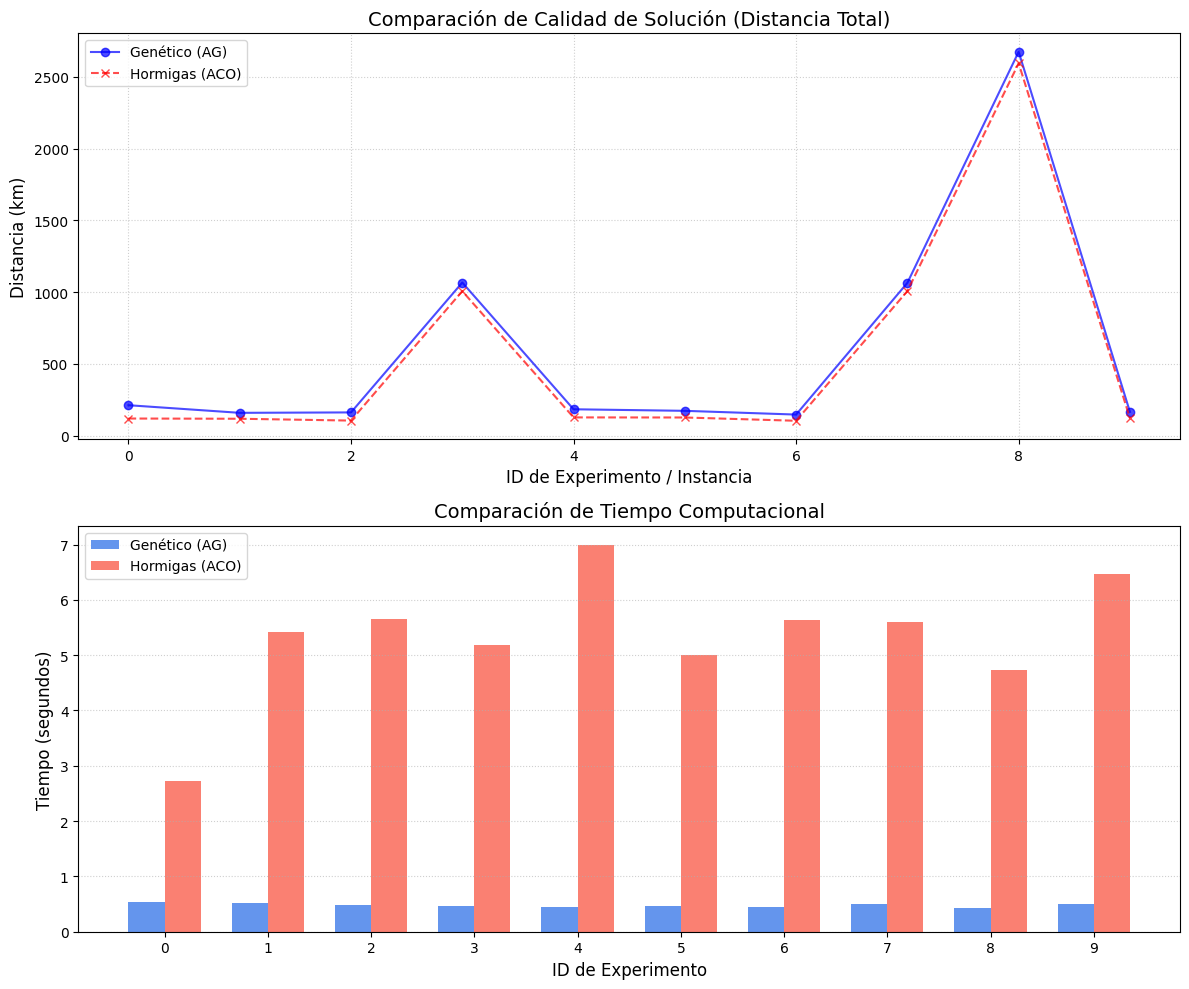

In [109]:
df = generar_reporte_completo(grafos_40)

In [110]:
df.to_csv("Reporte_Comparativo_TSP.csv", index=False)
df

,ID Exp,Nodos (Cant),Ref. Dirección (Nodo 0),Distancia AG,Distancia ACO,Tiempo AG (s),Tiempo ACO (s),Solucion AG,Solucion ACO,Mejor Método
0,0,40,"GAZA 1333, BEATRIZ HERNANDEZ...",211.6612,118.8803,0.5452,2.7180,"[24, 12, 0, 34, 6, 5, 37, 27, 1, 17, 3, 16, 15...","[24, 38, 39, 14, 5, 37, 21, 27, 4, 20, 30, 11,...",ACO
1,1,40,"MONTE HIMALAYA 1416, FEDERALISMO...",158.5591,117.3042,0.5159,5.4100,"[20, 23, 29, 7, 38, 24, 16, 19, 1, 32, 26, 6, ...","[25, 4, 0, 3, 27, 31, 12, 34, 17, 5, 35, 10, 6...",ACO
2,2,40,"AV ESPANA 1092, MODERNA...",161.4905,104.5264,0.4775,5.6569,"[3, 30, 38, 22, 6, 37, 31, 32, 0, 33, 9, 29, 3...","[23, 18, 7, 37, 31, 32, 0, 33, 9, 30, 6, 19, 1...",ACO
3,3,40,"MANUEL RIVERA C 2818, JARDINES DEL NILO...",1066.6842,1006.8047,0.4625,5.1805,"[35, 39, 20, 7, 26, 33, 15, 6, 18, 34, 0, 8, 3...","[15, 33, 30, 6, 4, 27, 18, 24, 2, 16, 12, 1, 1...",ACO
4,4,40,"AV LAS TORRES 1896, VILLA FONTANA DIAMAN...",183.3481,126.6610,0.4417,6.9883,"[17, 24, 21, 18, 14, 34, 13, 36, 19, 30, 38, 1...","[37, 18, 15, 8, 12, 5, 10, 30, 38, 21, 11, 4, ...",ACO
5,5,40,"MONTES MARCIANO 2173, SAN VICENTE...",172.5299,126.0836,0.4566,5.0082,"[27, 9, 11, 39, 35, 19, 2, 4, 6, 8, 12, 17, 14...","[24, 39, 34, 33, 3, 23, 28, 7, 10, 26, 29, 11,...",ACO
6,6,40,"CIRCUITO REAL S 0, REAL QUINTAS DEL VALL...",146.4203,103.2139,0.4459,5.6400,"[11, 24, 29, 8, 22, 0, 17, 18, 34, 31, 33, 16,...","[34, 17, 18, 31, 0, 33, 13, 12, 6, 27, 26, 20,...",ACO
7,7,40,"MONTE HIMALAYA 1416, FEDERALISMO...",1064.5194,1007.1628,0.5057,5.5955,"[16, 18, 20, 21, 17, 19, 32, 39, 36, 7, 29, 10...","[27, 11, 5, 10, 7, 39, 36, 29, 32, 30, 19, 15,...",ACO
8,8,40,"AV ISALA RAZA 2460, JARDINES DE LA CRUZ...",2674.8569,2594.4782,0.4333,4.7256,"[7, 19, 31, 4, 39, 15, 11, 22, 10, 0, 6, 9, 3,...","[31, 15, 11, 28, 35, 5, 19, 1, 17, 7, 8, 33, 3...",ACO
9,9,40,"OBELISCO 138, AGRICOLA...",165.1878,121.5885,0.5006,6.4629,"[37, 8, 18, 38, 15, 6, 13, 9, 4, 20, 36, 17, 3...","[4, 20, 16, 27, 30, 9, 25, 3, 5, 26, 1, 13, 10...",ACO


In [111]:
def normalizar_ciclo(ruta):
    """
    Rota la ruta para que empiece por el nodo con el ID más bajo.
    Ejemplo: [3, 5, 0, 9] -> [0, 9, 3, 5]
    """
    if not ruta: return []
    
    min_nodo = min(ruta)
    idx = ruta.index(min_nodo)
    
    # Tomamos desde el menor hasta el final + del principio hasta el menor
    ruta_rotada = ruta[idx:] + ruta[:idx]
    
    return ruta_rotada

In [112]:
df['Ruta Normalizada AG'] = df['Solucion AG'].apply(lambda x: normalizar_ciclo(eval(x)))
df['Ruta Normalizada ACO'] = df['Solucion ACO'].apply(lambda x  : normalizar_ciclo(eval(x)))
df

,ID Exp,Nodos (Cant),Ref. Dirección (Nodo 0),Distancia AG,Distancia ACO,Tiempo AG (s),Tiempo ACO (s),Solucion AG,Solucion ACO,Mejor Método,Ruta Normalizada AG,Ruta Normalizada ACO
0,0,40,"GAZA 1333, BEATRIZ HERNANDEZ...",211.6612,118.8803,0.5452,2.7180,"[24, 12, 0, 34, 6, 5, 37, 27, 1, 17, 3, 16, 15...","[24, 38, 39, 14, 5, 37, 21, 27, 4, 20, 30, 11,...",ACO,"[0, 34, 6, 5, 37, 27, 1, 17, 3, 16, 15, 26, 7,...","[0, 12, 9, 22, 28, 24, 24, 38, 39, 14, 5, 37, ..."
1,1,40,"MONTE HIMALAYA 1416, FEDERALISMO...",158.5591,117.3042,0.5159,5.4100,"[20, 23, 29, 7, 38, 24, 16, 19, 1, 32, 26, 6, ...","[25, 4, 0, 3, 27, 31, 12, 34, 17, 5, 35, 10, 6...",ACO,"[0, 25, 21, 14, 8, 28, 17, 31, 12, 27, 10, 5, ...","[0, 3, 27, 31, 12, 34, 17, 5, 35, 10, 6, 26, 3..."
2,2,40,"AV ESPANA 1092, MODERNA...",161.4905,104.5264,0.4775,5.6569,"[3, 30, 38, 22, 6, 37, 31, 32, 0, 33, 9, 29, 3...","[23, 18, 7, 37, 31, 32, 0, 33, 9, 30, 6, 19, 1...",ACO,"[0, 33, 9, 29, 34, 12, 8, 26, 11, 25, 5, 19, 1...","[0, 33, 9, 30, 6, 19, 14, 4, 20, 22, 35, 38, 1..."
3,3,40,"MANUEL RIVERA C 2818, JARDINES DEL NILO...",1066.6842,1006.8047,0.4625,5.1805,"[35, 39, 20, 7, 26, 33, 15, 6, 18, 34, 0, 8, 3...","[15, 33, 30, 6, 4, 27, 18, 24, 2, 16, 12, 1, 1...",ACO,"[0, 8, 30, 27, 4, 36, 37, 10, 3, 22, 5, 13, 1,...","[0, 26, 37, 36, 8, 15, 15, 33, 30, 6, 4, 27, 1..."
4,4,40,"AV LAS TORRES 1896, VILLA FONTANA DIAMAN...",183.3481,126.6610,0.4417,6.9883,"[17, 24, 21, 18, 14, 34, 13, 36, 19, 30, 38, 1...","[37, 18, 15, 8, 12, 5, 10, 30, 38, 21, 11, 4, ...",ACO,"[0, 17, 24, 21, 18, 14, 34, 13, 36, 19, 30, 38...","[0, 7, 20, 35, 31, 3, 34, 6, 13, 36, 19, 14, 3..."
5,5,40,"MONTES MARCIANO 2173, SAN VICENTE...",172.5299,126.0836,0.4566,5.0082,"[27, 9, 11, 39, 35, 19, 2, 4, 6, 8, 12, 17, 14...","[24, 39, 34, 33, 3, 23, 28, 7, 10, 26, 29, 11,...",ACO,"[0, 20, 36, 38, 32, 37, 13, 31, 5, 1, 21, 18, ...","[0, 27, 16, 30, 25, 38, 36, 14, 17, 12, 20, 22..."
6,6,40,"CIRCUITO REAL S 0, REAL QUINTAS DEL VALL...",146.4203,103.2139,0.4459,5.6400,"[11, 24, 29, 8, 22, 0, 17, 18, 34, 31, 33, 16,...","[34, 17, 18, 31, 0, 33, 13, 12, 6, 27, 26, 20,...",ACO,"[0, 17, 18, 34, 31, 33, 16, 9, 39, 7, 25, 5, 3...","[0, 33, 13, 12, 6, 27, 26, 20, 19, 28, 11, 24,..."
7,7,40,"MONTE HIMALAYA 1416, FEDERALISMO...",1064.5194,1007.1628,0.5057,5.5955,"[16, 18, 20, 21, 17, 19, 32, 39, 36, 7, 29, 10...","[27, 11, 5, 10, 7, 39, 36, 29, 32, 30, 19, 15,...",ACO,"[0, 12, 23, 8, 35, 22, 33, 34, 14, 13, 3, 38, ...","[0, 38, 34, 3, 13, 14, 33, 25, 6, 2, 27, 27, 1..."
8,8,40,"AV ISALA RAZA 2460, JARDINES DE LA CRUZ...",2674.8569,2594.4782,0.4333,4.7256,"[7, 19, 31, 4, 39, 15, 11, 22, 10, 0, 6, 9, 3,...","[31, 15, 11, 28, 35, 5, 19, 1, 17, 7, 8, 33, 3...",ACO,"[0, 6, 9, 3, 28, 1, 33, 27, 17, 20, 13, 21, 8,...","[0, 30, 37, 38, 3, 6, 25, 34, 9, 10, 22, 39, 4..."
9,9,40,"OBELISCO 138, AGRICOLA...",165.1878,121.5885,0.5006,6.4629,"[37, 8, 18, 38, 15, 6, 13, 9, 4, 20, 36, 17, 3...","[4, 20, 16, 27, 30, 9, 25, 3, 5, 26, 1, 13, 10...",ACO,"[0, 35, 14, 2, 12, 24, 11, 37, 8, 18, 38, 15, ...","[0, 39, 4, 4, 20, 16, 27, 30, 9, 25, 3, 5, 26,..."


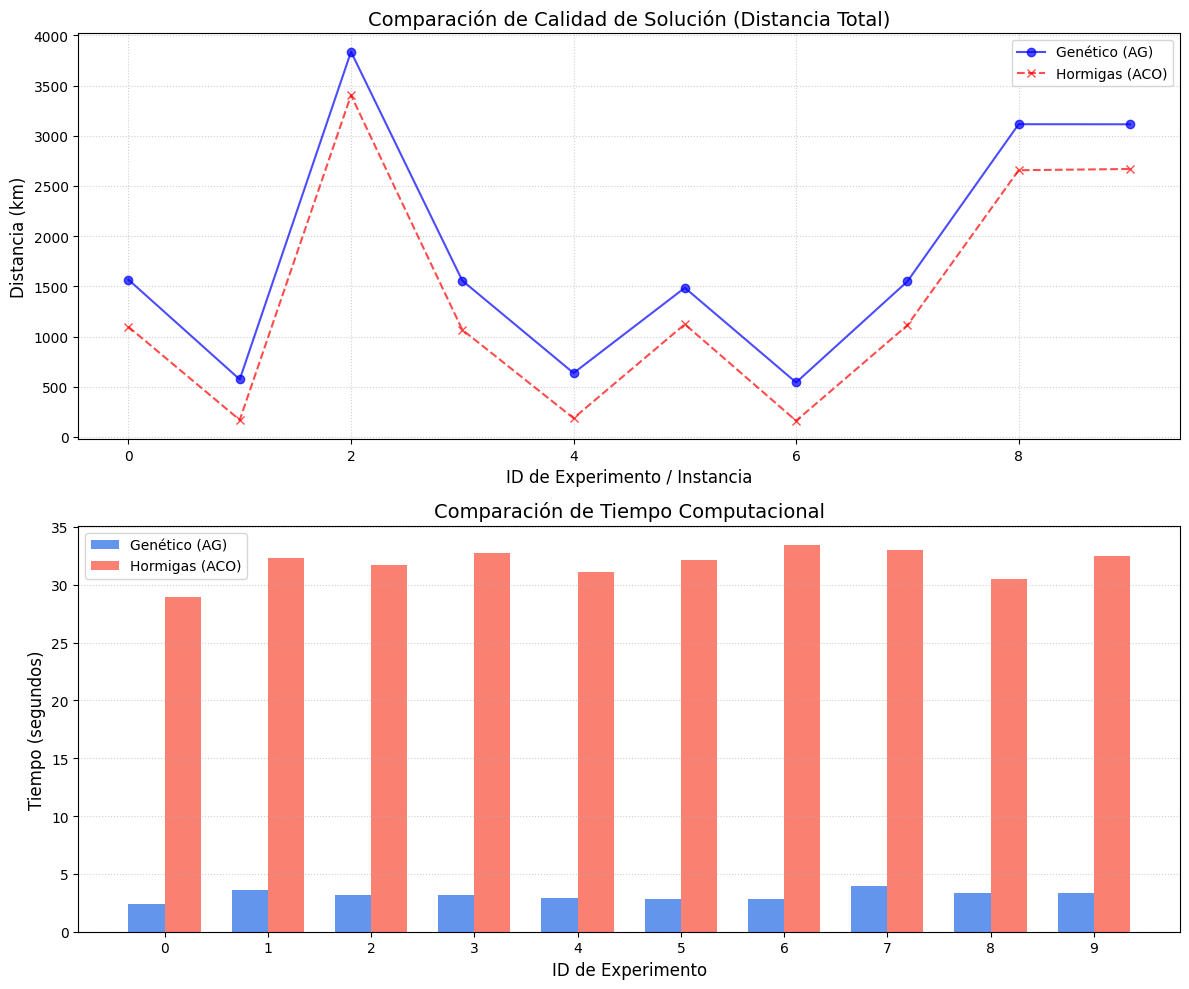

,ID Exp,Nodos (Cant),Ref. Dirección (Nodo 0),Distancia AG,Distancia ACO,Tiempo AG (s),Tiempo ACO (s),Solucion AG,Solucion ACO,Mejor Método,Ruta Normalizada AG,Ruta Normalizada ACO
0,0,100,"GAZA 1333, BEATRIZ HERNANDEZ...",1566.2950,1096.7244,2.3769,28.9293,"[68, 61, 77, 14, 53, 93, 23, 74, 27, 21, 78, 8...","[79, 25, 13, 8, 34, 12, 0, 84, 36, 65, 22, 91,...",ACO,"[0, 73, 37, 71, 1, 3, 49, 97, 25, 19, 40, 84, ...","[0, 84, 36, 65, 22, 91, 40, 76, 39, 58, 14, 96..."
1,1,100,"MONTE HIMALAYA 1416, FEDERALISMO...",573.1976,169.0657,3.6255,32.3460,"[16, 13, 36, 1, 27, 86, 79, 15, 87, 71, 25, 17...","[41, 88, 82, 35, 10, 5, 34, 17, 27, 12, 31, 90...",ACO,"[0, 3, 12, 4, 35, 88, 41, 19, 60, 43, 24, 66, ...","[0, 94, 58, 49, 11, 64, 15, 92, 81, 56, 97, 7,..."
2,2,100,"AV ESPANA 1092, MODERNA...",3836.1144,3403.5148,3.1439,31.6987,"[58, 15, 90, 64, 86, 18, 54, 71, 38, 77, 88, 1...","[60, 39, 67, 92, 75, 69, 1, 16, 53, 21, 47, 87...",ACO,"[0, 19, 55, 17, 91, 59, 24, 12, 44, 52, 47, 50...","[0, 95, 41, 62, 32, 34, 81, 27, 29, 13, 42, 61..."
3,3,100,"MANUEL RIVERA C 2818, JARDINES DEL NILO...",1557.0157,1067.3294,3.1350,32.7817,"[35, 20, 28, 93, 97, 19, 16, 1, 82, 44, 13, 54...","[30, 33, 15, 55, 68, 6, 72, 4, 60, 80, 73, 34,...",ACO,"[0, 5, 7, 84, 78, 99, 25, 21, 88, 18, 12, 57, ...","[0, 37, 51, 36, 94, 56, 8, 30, 30, 33, 15, 55,..."
4,4,100,"AV LAS TORRES 1896, VILLA FONTANA DIAMAN...",636.5992,186.9950,2.8933,31.1318,"[88, 72, 8, 59, 85, 64, 39, 69, 87, 98, 61, 70...","[15, 8, 85, 84, 72, 76, 88, 14, 19, 66, 36, 13...",ACO,"[0, 42, 34, 82, 14, 37, 66, 48, 90, 84, 41, 54...","[0, 42, 56, 69, 81, 39, 55, 91, 57, 86, 94, 9,..."
5,5,100,"MONTES MARCIANO 2173, SAN VICENTE...",1485.6282,1122.7207,2.8605,32.1507,"[18, 65, 81, 19, 90, 8, 12, 78, 58, 86, 24, 85...","[0, 27, 84, 50, 30, 46, 25, 40, 62, 44, 54, 43...",ACO,"[0, 40, 84, 25, 45, 22, 97, 35, 47, 44, 74, 57...","[0, 27, 84, 50, 30, 46, 25, 40, 62, 44, 54, 43..."
6,6,100,"CIRCUITO REAL S 0, REAL QUINTAS DEL VALL...",542.8400,161.1747,2.8333,33.4230,"[56, 78, 45, 50, 41, 62, 6, 12, 99, 53, 1, 10,...","[59, 61, 68, 90, 38, 30, 36, 37, 2, 98, 95, 3,...",ACO,"[0, 70, 76, 43, 27, 55, 93, 44, 91, 92, 22, 20...","[0, 33, 58, 45, 50, 76, 31, 70, 17, 62, 18, 41..."
7,7,100,"MONTE HIMALAYA 1416, FEDERALISMO...",1549.0352,1112.3263,3.9953,32.9703,"[94, 45, 29, 55, 30, 92, 63, 56, 68, 6, 90, 97...","[74, 90, 64, 34, 3, 14, 13, 97, 25, 6, 50, 63,...",ACO,"[0, 50, 81, 32, 77, 7, 10, 53, 28, 89, 13, 64,...","[0, 22, 35, 8, 44, 24, 4, 23, 98, 67, 75, 12, ..."
8,8,100,"AV ISALA RAZA 2460, JARDINES DE LA CRUZ...",3114.8846,2656.3885,3.3358,30.4812,"[33, 84, 45, 25, 47, 21, 95, 19, 29, 32, 96, 2...","[64, 89, 86, 15, 28, 63, 60, 11, 72, 19, 5, 35...",ACO,"[0, 13, 68, 33, 84, 45, 25, 47, 21, 95, 19, 29...","[0, 62, 83, 40, 13, 21, 88, 66, 10, 34, 9, 85,..."
9,9,100,"OBELISCO 138, AGRICOLA...",3113.9444,2668.8403,3.3199,32.4746,"[75, 45, 73, 85, 30, 31, 46, 82, 13, 3, 60, 87...","[42, 8, 58, 55, 37, 66, 33, 57, 22, 81, 62, 64...",ACO,"[0, 63, 89, 94, 43, 93, 50, 92, 56, 64, 37, 33...","[0, 35, 14, 98, 44, 88, 99, 2, 74, 12, 24, 11,..."


In [118]:
df = generar_reporte_completo(grafos_100)
df.to_csv("Reporte_Comparativo_TSP_100nodos.csv", index=False)
df['Ruta Normalizada AG'] = df['Solucion AG'].apply(lambda x: normalizar_ciclo(eval(x)))
df['Ruta Normalizada ACO'] = df['Solucion ACO'].apply(lambda x  : normalizar_ciclo(eval(x)))
df